# XML, SVG and images
> Build XML element trees, serialize them, and display HTML, SVG and images in notebooks

> Adapted from the upstream BasedPL docs notebook. `]help` magic cells are omitted (REPL-only, not executable BPL). The image-processing section works against the bundled `puppy.jpg` in this folder.

## Elements

Here `text` makes `text` elements. The result is an ordinary keyed vector. Notebooks display it as HTML:

In [ ]:
text←•element "text"
label←["x":10 "y":20] text "a < b"
label

["tag":"text" "attrs":["x":10 "y":20] "children":"a < b"]

## XML

`•xml⁻¹` writes the XML text of an element tree. It escapes text:

In [ ]:
•xml⁻¹ label

<text x="10" y="20">a &lt; b</text>

A numeric vector attribute becomes space-separated numbers. An element with no children closes itself. `""` and `⍬` both mean no children:

In [ ]:
g←•element "g"
•xml⁻¹ ["fill":"red" "points":[1 2 3 4]] g ⍬

<g fill="red" points="1 2 3 4"/>

Children can be a vector of elements:

In [ ]:
•xml⁻¹ g [text 'a';text 'b']

<g><text>a</text><text>b</text></g>

Attribute names keep their case. Prefixed names such as `xlink:href` pass through unchanged.

## SVG

`width` and `height` set the picture's displayed size:

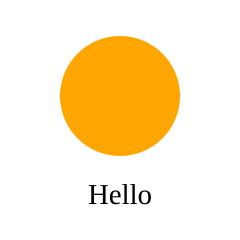

In [ ]:
circle←•element "circle"
c←["cx":50 "cy":40 "r":25 "fill":"orange"] circle ""
t←["x":50 "y":85 "text-anchor":"middle"] text "Hello"
pic←["width":240 "height":240] •svg [c t]
pic

Elements are keyed arrays with `tag`, `attrs` and `children` entries. Edit them using ordinary assignment. Display serializes the current tree.

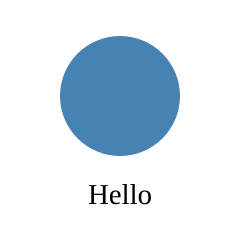

In [ ]:
pic.children₀.attrs.fill←"steelblue"
pic

Override `viewBox` with four numbers to choose the drawing coordinates.

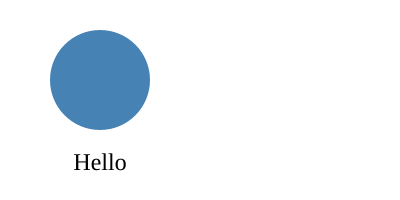

In [ ]:
["viewBox":[0 0 200 100] "width":400 "height":200] •svg pic.children

## Rich display

`F •mime Y` displays `Y` through the renderer that `F` holds. Display calls the renderer with `Y` as `⍵`. The renderer returns a keyed vector from MIME types to text, or to bytes for a binary type such as `image/png`. `F` holds the function in an array, written here with `ᵘ`, because a function to the left of `•mime` would form a train. This renderer shows the sum of `items`:

In [ ]:
total←{["text/plain":⍕+/⍵.items]}ᵘ •mime ["items":[1 2 3]]
total

6

The renderer isn't one of `total`'s keys. Changes in place keep the renderer. It always shows the current values:

In [ ]:
total.items+←10
total

36

`•mime` shows the bundle that display uses:

In [ ]:
•mime total

["text/plain":"36"]

A MIME type on the left displays text as that type:

In [ ]:
"text/markdown" •mime "**Bold** and *italic*"

**Bold** and *italic*

Python arrays implement `_repr_mimebundle_()`. `bpl(code, 'repl')` captures ordered events in `Result.events`. `Result.output` extracts their text. `⎕←` produces explicit text output. The native kernel, notebook magics and `bpl-nb --save` use the rich bundles.

## Images

`•image` displays a matrix of numbers from 0 to 1 as a greyscale picture. Here each pixel gets brighter with its distance from the centre:

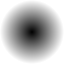

In [ ]:
r←31.5-⍨⍳64
pic←•image 1⌊32÷⍨√r²+⊗r²
pic

Pervasive functions keep the picture's renderer. `1-pic` is the picture's negative:

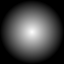

In [ ]:
1-pic

`•image⁻¹ pic` encodes the picture as PNG bytes. `"out.png" •nput png` would write them to a file:

In [ ]:
png←•image⁻¹ pic
8↑png

[137 80 78 71 13 10 26 10]ₓ

`•image` also reads PNG and JPEG files. A colour picture has a third axis, holding each pixel's red, green and blue:

In [ ]:
puppy←•image "examples/puppy.jpg"
⍴puppy

[200 300 3]ₓ

Windows, `↕`, can shrink it. With a second row of movements, `[2 2 ⋄ 2 2]↕puppy` cuts the photo into separate 2×2 blocks of pixels. Averaging each block halves both sides, to 150 pixels wide:

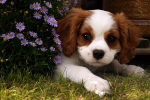

In [ ]:
small←•image 0.25×+/⍠[2 3] [2 2 ⋄ 2 2]↕puppy
small

Edge detection works on one brightness per pixel. An inner product with the standard luminance weights combines the three colours:

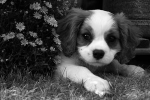

In [ ]:
grey←small+.×[0.299 0.587 0.114]
•image grey

A Laplacian kernel responds where brightness changes sharply. `3 3↕grey` gives the 3×3 neighbourhood of every pixel that has one:

In [ ]:
k←[0  1 0
   1 ¯4 1
   0  1 0]
win←3 3↕grey
⍴win

[98 148 3 3]ₓ

Multiplying each neighbourhood by the kernel and summing over the last two axes gives an edge strength for each pixel. Its absolute value shows the edges as bright lines:

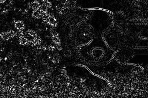

In [ ]:
edges←+/+/k×⍤2win
•image |edges